In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

data = pd.read_csv('./data/Housing.csv')

X = data['area'].values
y = data['price'].values


X_train, X_test, y_train, y_test = train_test_split(X ,y, test_size=0.2, random_state=42)
  
print(X_train[:5])
print(y_train[:5])

[ 645 4680 3671 1418 3609]
[ 333832.74307673 1701369.53479147 1280972.32209254  512523.16542581
 1291419.79524588]


In [4]:
#NORMALIZATION DATA : makes values small / close to zero so i can calculate (in between 0 and 1)
X_train = X_train / X_train.max()
y_train = y_train / y_train.max()
X_test = X_test / X_test.max()
y_test = y_test / y_test.max()

In [5]:
m = 0
b = 0 
learning_rate = 0.01
epochs = 10000
n = len(X_train)

for i in range(epochs):
    
    y_pred = m * X_train + b
    
    dm = (-2/n) * np.sum(X_train * (y_train - y_pred))
    db = (-2/n) * np.sum(y_train - y_pred)
    
    print("ERROR m: " , dm)
    print("ERROR b: " , db)

    m = m - learning_rate * dm
    b = b - learning_rate * db

print("Gradient Descent Slope:", m)
print("Gradient Descent Intercept:", b)


ERROR m:  -0.7132744812784381
ERROR b:  -1.0689616894919185
ERROR m:  -0.6960734961655886
ERROR b:  -1.0396684247209234
ERROR m:  -0.6793263185605979
ERROR b:  -1.011151876218799
ERROR m:  -0.6630209327436116
ERROR b:  -0.9833914745064213
ERROR m:  -0.6471456411853279
ERROR b:  -0.9563671948128821
ERROR m:  -0.6316890561208902
ERROR b:  -0.9300595426508899
ERROR m:  -0.6166400913469132
ERROR b:  -0.9044495397741502
ERROR m:  -0.6019879542357354
ERROR b:  -0.8795187105066167
ERROR m:  -0.587722137961144
ERROR b:  -0.8552490684337597
ERROR m:  -0.5738324139299742
ERROR b:  -0.8316231034462686
ERROR m:  -0.5603088244141287
ERROR b:  -0.808623769126854
ERROR m:  -0.5471416753777111
ERROR b:  -0.7862344704710645
ERROR m:  -0.5343215294941078
ERROR b:  -0.7644390519332716
ERROR m:  -0.5218391993479855
ERROR b:  -0.7432217857892142
ERROR m:  -0.5096857408173084
ERROR b:  -0.7225673608067177
ERROR m:  -0.49785244663061085
ERROR b:  -0.7024608712164271
ERROR m:  -0.4863308400948789
ERROR b:  -0

[0.15012582 0.87882393 0.69660425 ... 0.62978435 0.72838886 0.30164446]


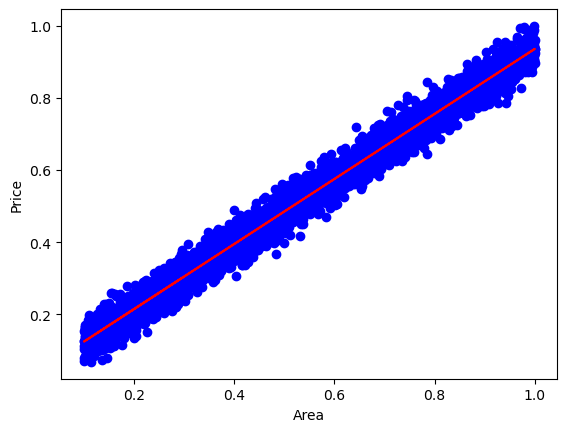

In [6]:
plt.scatter(X_train, y_train, color='blue')

y_pred_manual = m * X_train + b
plt.plot(X_train, y_pred_manual, color='red')
print(y_pred_manual)
plt.xlabel("Area")
plt.ylabel("Price")
plt.show()

In [7]:

learning_rate = np.array([0.01 , 0.02 , 0.03 ])
epochs = 10000
n = len(X_train)

mse = np.array([])

for i in range(learning_rate.size):
    
    m = 0
    b = 0
    
    for j in range(epochs):
        
        y_pred = m * X_train + b
        
        dm = (-2/n) * np.sum(X_train * (y_train - y_pred))
        db = (-2/n) * np.sum(y_train - y_pred)
        
        m = m - learning_rate[i] * dm
        b = b - learning_rate[i] * db
    
    loss = np.mean((y_train - (m * X_train + b)) ** 2)
    mse = np.append(mse, loss)
    
    print(f"LR={learning_rate[i]}, m={m}, b={b}, MSE={loss}")
    
# Loss tells how bad your prediction is.
# dm tells how to change m to reduce that loss.

LR=0.01, m=0.9027910470870819, b=0.033642474959405394, MSE=0.0009207909423532696
LR=0.02, m=0.9028190749300491, b=0.033626102538280224, MSE=0.0009207908893551238
LR=0.03, m=0.9028190761110476, b=0.033626101848401514, MSE=0.0009207908893551237


In [8]:
learning_rate = np.array([0.01 , 0.02 , 0.03 ])
epochs = 10000
n = len(X_test)

mse = np.array([])

for i in range(learning_rate.size):
    
    m = 0
    b = 0
    
    for j in range(epochs):
        
        y_pred = m * X_test + b
        
        dm = (-2/n) * np.sum(X_test * (y_test - y_pred))
        db = (-2/n) * np.sum(y_test - y_pred)
        
        m = m - learning_rate[i] * dm
        b = b - learning_rate[i] * db
    
    loss = np.mean((y_test - (m * X_test + b)) ** 2)
    mse = np.append(mse, loss)
    
    print(f"LR={learning_rate[i]}, m={m}, b={b}, MSE={loss}")



LR=0.01, m=0.9071604888013183, b=0.038517211148632706, MSE=0.0010229207040964843
LR=0.02, m=0.9072031981969104, b=0.0384921265829883, MSE=0.0010229205858628481
LR=0.03, m=0.9072032009447879, b=0.038492124969074, MSE=0.001022920585862848


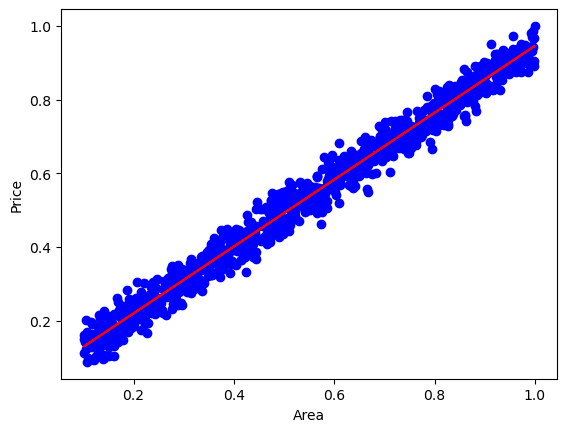

In [9]:
plt.scatter(X_test, y_test, color='blue')

y_pred_manual = m * X_test + b
plt.plot(X_test, y_pred_manual, color='red')

plt.xlabel("Area")
plt.ylabel("Price")
plt.show()